### Naive Bayes Classifier Task
### 문장에서 느껴지는 감정 예측
##### 다중 분류(Multiclass Classification)
- 비대면 심리 상담사로서 메세지를 전달한 환자에 대한 감정 데이터를 수집했다.
- 각 메세지 별로 감정이 표시되어 있다.
- 미래에 동일한 메세지를 보내는 환자에게 어떤 심리 치료가 적합할 수 있는지 알아보기 위한 모델을 구축한다.

In [71]:
import pandas as pd

f_df = pd.read_csv('./datasets/feeling.csv', sep=';')
f_df

,message,feeling
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy
...,...,...
17995,i just had a very brief time in the beanbag an...,sadness
17996,i am now turning and i feel pathetic that i am...,sadness
17997,i feel strong and good overall,joy
17998,i feel like this was such a rude comment and i...,anger


In [72]:
f_df.feeling.value_counts()

feeling
joy         6066
sadness     5216
anger       2434
fear        2149
love        1482
surprise     653
Name: count, dtype: int64

In [73]:
f_df = f_df[f_df.feeling != 'surprise']

In [74]:
from sklearn.preprocessing import LabelEncoder

feeling_encoder = LabelEncoder()
targets = feeling_encoder.fit_transform(f_df.feeling)
f_df['target'] = targets

C:\Users\Administrator\AppData\Local\Temp\ipykernel_7084\3722698594.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_df['target'] = targets


In [75]:
f_df.drop(labels=['feeling'], axis=1, inplace=True)
f_df

C:\Users\Administrator\AppData\Local\Temp\ipykernel_7084\2937068017.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_df.drop(labels=['feeling'], axis=1, inplace=True)


,message,target
0,im feeling quite sad and sorry for myself but ...,4
1,i feel like i am still looking at a blank canv...,4
2,i feel like a faithful servant,3
3,i am just feeling cranky and blue,0
4,i can have for a treat or if i am feeling festive,2
...,...,...
17995,i just had a very brief time in the beanbag an...,4
17996,i am now turning and i feel pathetic that i am...,4
17997,i feel strong and good overall,2
17998,i feel like this was such a rude comment and i...,0


In [76]:
f_df.target.value_counts()

target
2    6066
4    5216
0    2434
1    2149
3    1482
Name: count, dtype: int64

In [77]:
f_df.isna().sum()

message    0
target     0
dtype: int64

In [78]:
f_df.duplicated().sum()

1

In [79]:
f_df.drop_duplicates(inplace=True, ignore_index=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_7084\1749654.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_df.drop_duplicates(inplace=True, ignore_index=True)


In [80]:
f_df.duplicated().sum()

0

In [81]:
anger = f_df[f_df.target == 0].sample(1482, random_state=326)
fear = f_df[f_df.target == 1].sample(1482, random_state=326)
joy = f_df[f_df.target == 2].sample(1482, random_state=326)
love = f_df[f_df.target == 3]
sadness = f_df[f_df.target == 4].sample(1482, random_state=326)

f_df = pd.concat([anger, fear, joy, love, sadness]).reset_index(drop=True)

In [82]:
f_df.target.value_counts()

target
0    1482
1    1482
2    1482
3    1482
4    1482
Name: count, dtype: int64

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
train_test_split(f_df.message, 
                 f_df.target, 
                 stratify=f_df.target, 
                 test_size=0.3, 
                 random_state=124)

In [84]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

m_nb_pipe = Pipeline([('count_vectorizer', CountVectorizer()), ('multinomialNB', MultinomialNB())])

In [85]:
m_nb_pipe.fit(X_train.values, y_train)

Pipeline(steps=[('count_vectorizer', CountVectorizer()),
                ('multinomialNB', MultinomialNB())])

In [86]:
m_nb_pipe.score(X_test.values, y_test)

0.8029689608636977

In [87]:
feeling_encoder.classes_[m_nb_pipe.predict(['I just know that yesterday was my wife`s birthday'])]

array(['fear'], dtype=object)

In [88]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score)

def get_evaluation(y_test, prediction, proba, class_names=None):
    confusion = confusion_matrix(y_test, prediction)
    accuracy = accuracy_score(y_test, prediction)
    
    # 다중 분류일 경우 precision과 recall, f1, roc_auc에 average 인자가 필요.
    # macro: 타겟별 F1점수 산술 평군, 모든 타겟을 동일한 비중으로 취급
    # micro: "정확도" 평가 지표와 수학적으로 동일한 값
    # weighted: 타겟별 F1점수에 해당 샘플 수만큼 가중치 부여, 다수 클래스의 영향력이 커짐
    precision = precision_score(y_test, prediction, average='weighted')
    recall = recall_score(y_test, prediction, average='weighted')
    f1 = f1_score(y_test, prediction, average='weighted')
    # ovr(One-vs-Rest): 여러 개의 타겟 중 1개 뽑아서 나머지와 비교(O, X), 직관적, 많이 씀
    # ovo(One-vs-One): 여러 개의 타겟 중 2개 뽑아서 서로 비교(A, B), 세밀함, 특별한 상황에서 씀
    roc_auc = roc_auc_score(y_test, proba, multi_class='ovr', average='weighted')

    print('오차 행렬')
    print(confusion)
    print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}')
    print("#" * 75)
    
    # 클래스 개수에 따라 유동적으로 크기 조절
    num_classes = len(np.unique(y_test))
    fig_width = max(10, num_classes * 1.5)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(fig_width, 5))
    titles_options = [("Confusion matrix", None), ("Normalized confusion matrix", "true")]

    for (title, normalize), ax in zip(titles_options, axes.flatten()):
        disp = ConfusionMatrixDisplay.from_predictions(
            y_true=y_test, y_pred=prediction,
            display_labels=class_names, # 클래스 이름 표시
            ax=ax, 
            cmap=plt.cm.Blues, 
            normalize=normalize,
            values_format='.2f' if normalize else 'd'
        )
        disp.ax_.set_title(title)
        
        # 레이블이 많을 경우 45도 회전하여 겹침 방지
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    plt.tight_layout()
    plt.show()

In [89]:
prediction = m_nb_pipe.predict(X_test.values)
proba = m_nb_pipe.predict_proba(X_test.values)

In [90]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.86      0.81      0.83       444
           1       0.81      0.82      0.82       445
           2       0.78      0.75      0.76       445
           3       0.77      0.87      0.82       444
           4       0.80      0.76      0.78       445

    accuracy                           0.80      2223
   macro avg       0.80      0.80      0.80      2223
weighted avg       0.80      0.80      0.80      2223



오차 행렬
[[361  29  13  20  21]
 [ 22 366  14  17  26]
 [ 13  23 333  55  21]
 [  5   5  33 387  14]
 [ 21  30  33  23 338]]
정확도: 0.8030, 정밀도: 0.8041, 재현율: 0.8030, F1: 0.8026, AUC: 0.9450
###########################################################################


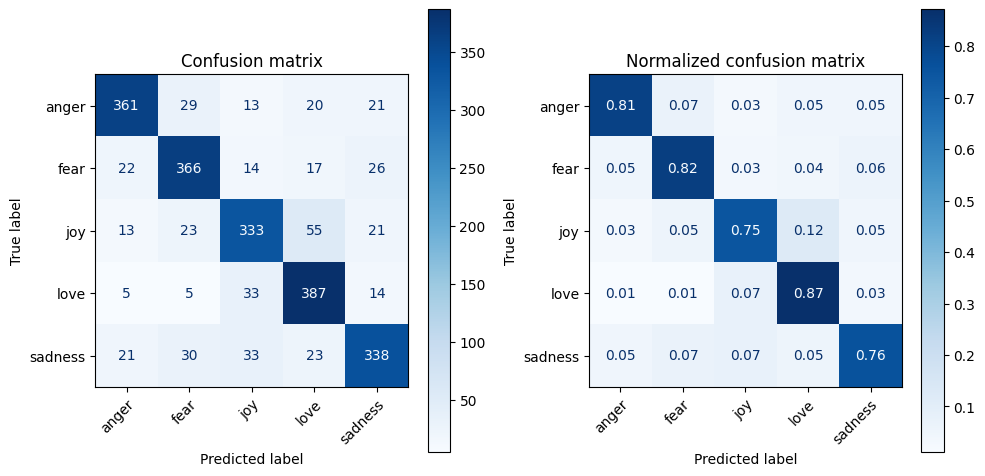

In [91]:
get_evaluation(y_test, prediction, proba, class_names=feeling_encoder.classes_)